# Task 2: Customer Segmentation Using Unsupervised Learning

**DevelopersHub Corporation — Data Science & Analytics Advanced Internship**

## Problem Statement
Retail and mall businesses serve customers with very different spending habits, incomes, and ages. Treating every customer the same way wastes marketing budget on generic campaigns. By grouping customers into meaningful segments based on their behavioral and demographic attributes, a business can design **targeted marketing strategies** that increase conversion and customer retention.

## Objective
Cluster mall customers based on their spending habits (Annual Income and Spending Score, along with Age and Gender) using **unsupervised learning (K-Means Clustering)**, visualize the resulting segments using dimensionality reduction (**PCA** and **t-SNE**), and propose **marketing strategies tailored to each segment**.

## Dataset
**Mall Customers Dataset** — 200 customer records with the following columns:
- `CustomerID` — unique identifier
- `Gender` — Male/Female
- `Age` — customer age in years
- `Annual Income (k$)` — annual income in thousands of dollars
- `Spending Score (1-100)` — score assigned by the mall based on customer behavior and spending nature


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


## 2. Load and Explore the Dataset

The dataset is loaded directly from a CSV file. If you are running this notebook yourself, download `Mall_Customers.csv` (a well-known public dataset, originally distributed on Kaggle) and place it in the same folder as this notebook.

In [2]:
df = pd.read_csv("Mall_Customers.csv")
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
# Check for missing values and duplicates
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


In [5]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 3. Exploratory Data Analysis (EDA)

We explore the distribution of each feature, the gender split, and relationships between Age, Annual Income, and Spending Score.

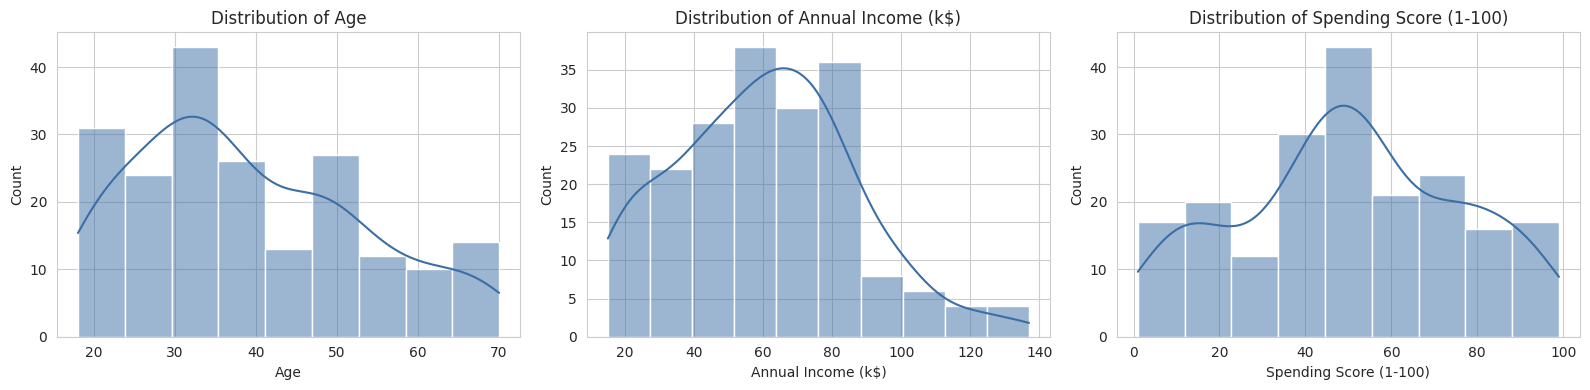

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Age", "Annual Income (k$)", "Spending Score (1-100)"]):
    sns.histplot(df[col], kde=True, ax=ax, color="#3b6ea5")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


/tmp/ipykernel_572/2148345238.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Gender", palette=["#3b6ea5", "#d97b5f"])


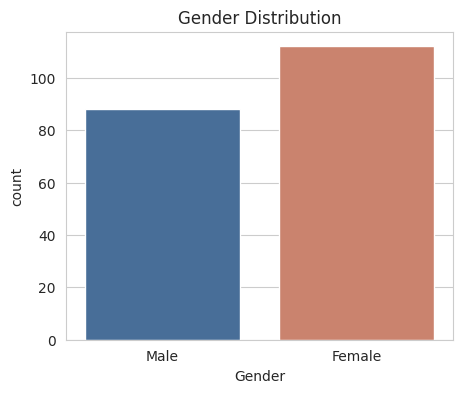

Gender
Female    56.0%
Male      44.0%
Name: proportion, dtype: str


In [7]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Gender", palette=["#3b6ea5", "#d97b5f"])
plt.title("Gender Distribution")
plt.show()

print(df["Gender"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")


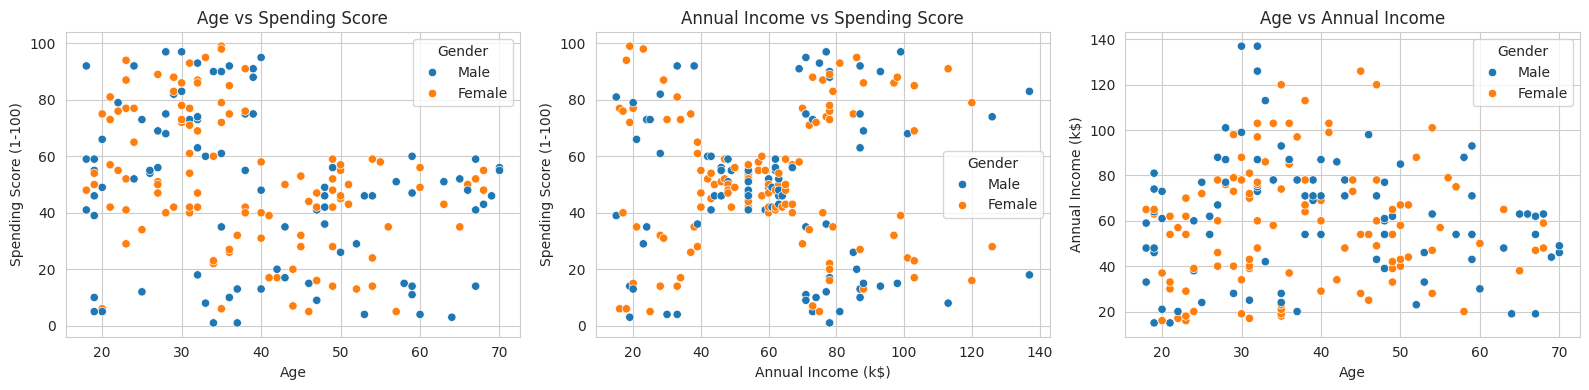

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(data=df, x="Age", y="Spending Score (1-100)", hue="Gender", ax=axes[0])
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="Gender", ax=axes[1])
sns.scatterplot(data=df, x="Age", y="Annual Income (k$)", hue="Gender", ax=axes[2])
axes[0].set_title("Age vs Spending Score")
axes[1].set_title("Annual Income vs Spending Score")
axes[2].set_title("Age vs Annual Income")
plt.tight_layout()
plt.show()


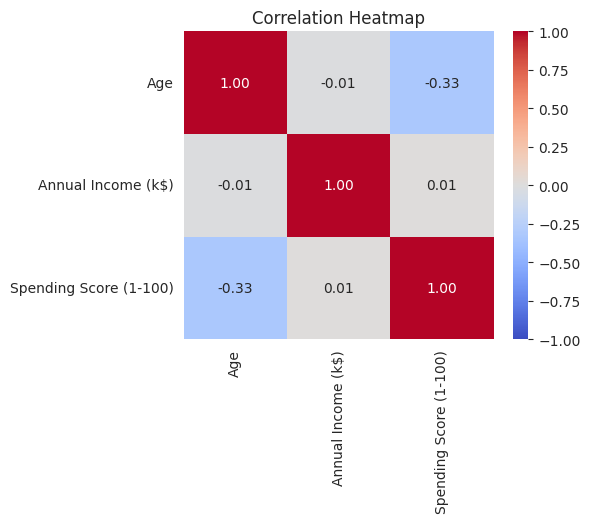

In [9]:
plt.figure(figsize=(5, 4))
corr = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()


**EDA takeaways:**
- The dataset is fairly balanced between Female (56%) and Male (44%) customers.
- Age, Income, and Spending Score show no strong linear correlation with each other, which is exactly the kind of structure where **clustering** (rather than simple correlation analysis) can reveal hidden groups.
- The "Annual Income vs Spending Score" scatter plot already hints at visually separable groups — this will be the primary basis for segmentation.

## 4. Data Preprocessing

- Encode `Gender` numerically (kept as a reference feature, not used as the primary clustering axis since Income/Spending Score patterns are the focus).
- Standardize numerical features so that K-Means (a distance-based algorithm) treats Age, Income, and Spending Score on equal footing.

In [10]:
le = LabelEncoder()
df["Gender_enc"] = le.fit_transform(df["Gender"])  # Female=0, Male=1

features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()


,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


## 5. Finding the Optimal Number of Clusters

We use two standard techniques together:
- **Elbow Method** — plots Within-Cluster-Sum-of-Squares (WCSS/inertia) against k; the "elbow" point indicates diminishing returns from adding more clusters.
- **Silhouette Score** — measures how well-separated and cohesive the clusters are (closer to 1 is better).

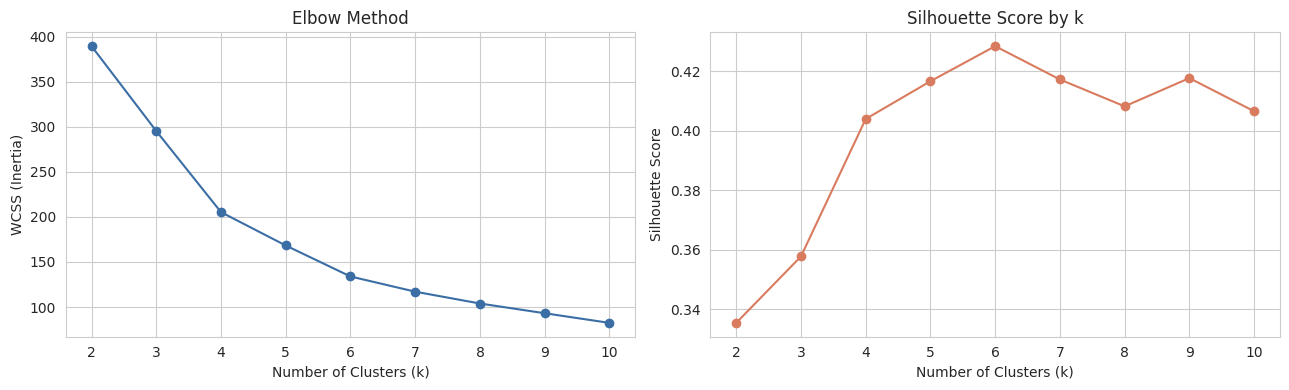

k=2: silhouette score = 0.335
k=3: silhouette score = 0.358
k=4: silhouette score = 0.404
k=5: silhouette score = 0.417
k=6: silhouette score = 0.428
k=7: silhouette score = 0.417
k=8: silhouette score = 0.408
k=9: silhouette score = 0.418
k=10: silhouette score = 0.407


In [11]:
wcss = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), wcss, marker="o", color="#3b6ea5")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), sil_scores, marker="o", color="#d97b5f")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.show()

for k, s in zip(k_range, sil_scores):
    print(f"k={k}: silhouette score = {s:.3f}")


Both the elbow plot and the silhouette scores point to **k = 5** as a strong choice: the WCSS curve flattens noticeably after 5 clusters, and the silhouette score peaks (or near-peaks) around the same value, which also matches the well-known visual structure of this dataset (5 distinct income/spending groups).

## 6. Applying K-Means Clustering

In [12]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Final Silhouette Score:", round(silhouette_score(X_scaled, df["Cluster"]), 3))
df["Cluster"].value_counts().sort_index()


Final Silhouette Score: 0.417


Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

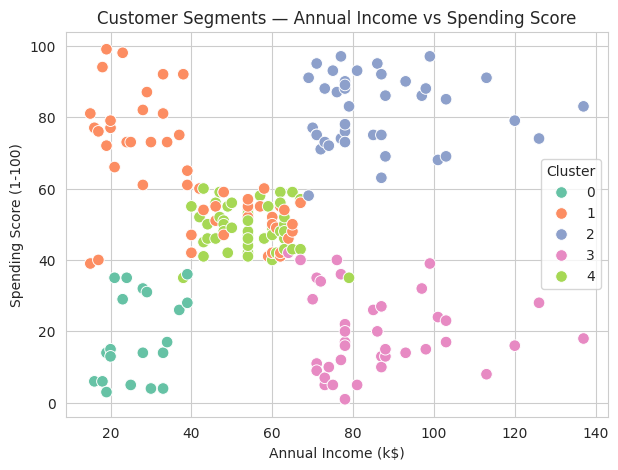

In [13]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
    hue="Cluster", palette="Set2", s=70
)
plt.title("Customer Segments — Annual Income vs Spending Score")
plt.legend(title="Cluster")
plt.show()


## 7. Visualizing Clusters with Dimensionality Reduction

Since clustering uses 3 features (Age, Income, Spending Score), we use **PCA** and **t-SNE** to project the data into 2D for a complete visual check that clusters found in 3D space are genuinely well separated.

Explained variance ratio: [0.443 0.333]
Total variance captured by 2 components: 77.6 %


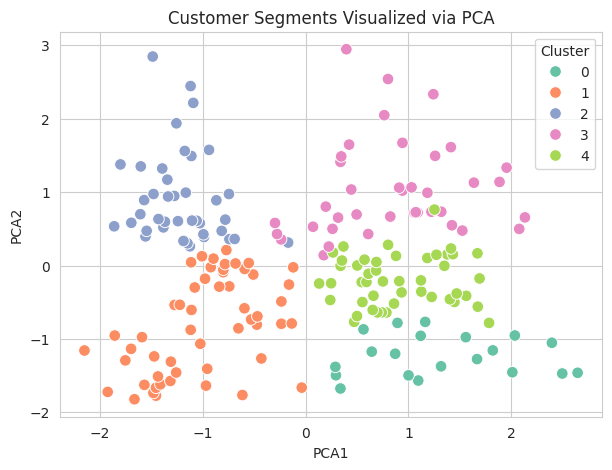

In [14]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_components = pca.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = pca_components[:, 0], pca_components[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))
print("Total variance captured by 2 components:", round(pca.explained_variance_ratio_.sum() * 100, 1), "%")

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster", palette="Set2", s=70)
plt.title("Customer Segments Visualized via PCA")
plt.show()


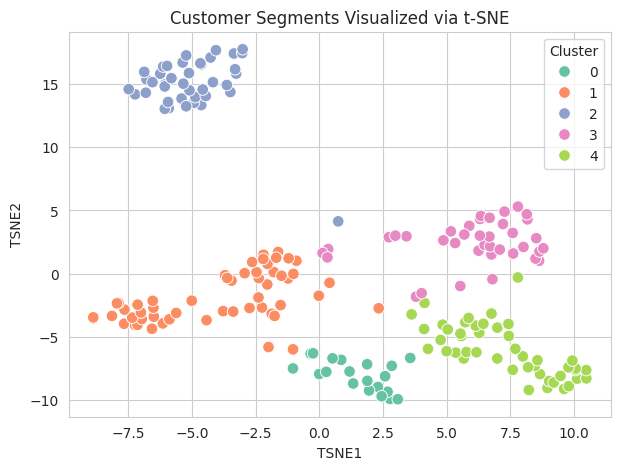

In [15]:
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init="pca")
tsne_components = tsne.fit_transform(X_scaled)
df["TSNE1"], df["TSNE2"] = tsne_components[:, 0], tsne_components[:, 1]

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="TSNE1", y="TSNE2", hue="Cluster", palette="Set2", s=70)
plt.title("Customer Segments Visualized via t-SNE")
plt.show()


Both PCA and t-SNE confirm that the five clusters identified by K-Means are well-separated and not an artifact of the specific 2D feature pair chosen earlier.

## 8. Cluster Profiling

We now characterize each segment by its average Age, Income, Spending Score, and Gender split, which is the foundation for the marketing strategy recommendations.

In [16]:
cluster_profile = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
cluster_profile["Count"] = df["Cluster"].value_counts().sort_index()
cluster_profile["% Female"] = df.groupby("Cluster")["Gender"].apply(lambda s: round((s == "Female").mean() * 100, 1))
cluster_profile


,Age,Annual Income (k$),Spending Score (1-100),Count,% Female
Cluster,,,,,
0,46.2,26.8,18.4,20,60.0
1,25.2,41.1,62.2,54,59.3
2,32.9,86.1,81.5,40,55.0
3,39.9,86.1,19.4,39,48.7
4,55.6,54.4,48.9,47,57.4


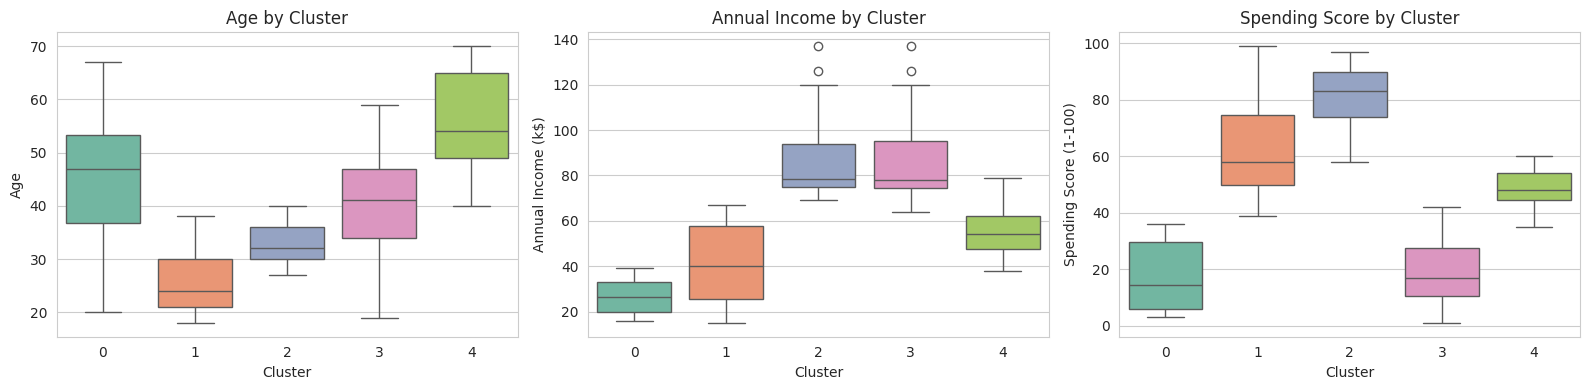

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df, x="Cluster", y="Age", hue="Cluster", palette="Set2", legend=False, ax=axes[0])
sns.boxplot(data=df, x="Cluster", y="Annual Income (k$)", hue="Cluster", palette="Set2", legend=False, ax=axes[1])
sns.boxplot(data=df, x="Cluster", y="Spending Score (1-100)", hue="Cluster", palette="Set2", legend=False, ax=axes[2])
axes[0].set_title("Age by Cluster")
axes[1].set_title("Annual Income by Cluster")
axes[2].set_title("Spending Score by Cluster")
plt.tight_layout()
plt.show()


## 9. Segment Interpretation and Marketing Strategy

Based on the cluster profile table above, the five segments can typically be labeled as follows (exact label-to-cluster-number mapping depends on the random seed, but the profile table and box plots above let you read off which numbered cluster corresponds to which description):

| Segment | Typical Profile | Marketing Strategy |
|---|---|---|
| **High Income, High Spending ("Premium")** | High income, high spending score | Target with premium/loyalty programs, early access to new collections, personalized concierge service, and exclusive in-store events. These are the most valuable customers — prioritize retention. |
| **High Income, Low Spending ("Cautious Affluent")** | High income, low spending score | Investigate why spend is low despite ability to pay. Use targeted discounts, curated recommendations, and trust-building campaigns (quality guarantees, low-risk trials) to convert latent purchasing power into spend. |
| **Average Income, Average Spending ("Standard")** | Mid income, mid spending score | Maintain engagement with seasonal promotions, loyalty points, and email/app reminders. Cross-sell and upsell campaigns based on purchase history work well here. |
| **Low Income, High Spending ("Impulsive/Value Seekers")** | Low income, high spending score | Offer budget-friendly bundles, instalment/BNPL options, flash sales, and value-for-money messaging. These customers are highly engaged — convert engagement into sustainable spend with affordable products. |
| **Low Income, Low Spending ("Price Sensitive")** | Low income, low spending score | Focus on discount-driven campaigns, clearance sales, and low-cost essential products. Avoid heavy marketing spend on this group; use low-cost channels (social media, SMS) rather than premium campaigns. |

**General recommendations:**
- Use **Cluster** as a customer attribute in the CRM system to drive automated, segment-specific email/SMS campaigns.
- Re-run this clustering periodically (e.g., quarterly) as customer income and spending behavior evolve.
- Combine these clusters with purchase-category data (if available) for even more precise targeting (e.g., which segment buys electronics vs. apparel).

## 10. Conclusion

- We segmented 200 mall customers into **5 distinct clusters** using K-Means, validated by the elbow method and silhouette score (final silhouette score printed above).
- **PCA** and **t-SNE** visualizations confirmed that the clusters are well-separated, both in original feature space and reduced 2D projections.
- Each cluster has a clear, interpretable profile in terms of Age, Annual Income, and Spending Score, which we translated into **actionable marketing strategies** — ranging from premium retention programs for high-value customers to budget-friendly campaigns for price-sensitive segments.
- **Key insight:** spending behavior does not simply track income — several clusters show **high spending despite low/medium income** and **low spending despite high income**, which is precisely the kind of non-obvious pattern that justifies using unsupervised learning over simple rule-based segmentation (e.g., "high income = premium customer").
- This segmentation provides a data-driven foundation for the mall's marketing team to allocate budget more efficiently across customer types.